## Lorenz63 System

This notebook evaluates the effectiveness our proposed **KoopSTD** on the well-known Lorenz63 system.

The dataset consists of segments extracted from 500-second simulated trajectories, encompassing five distinct behaviors: line-like, ring-like, Periodic[1-1-2-2], Periodic[1-2], and Chaotic dynamics. For each behavioral type, we include 20 randomly sampled 20-second clips.

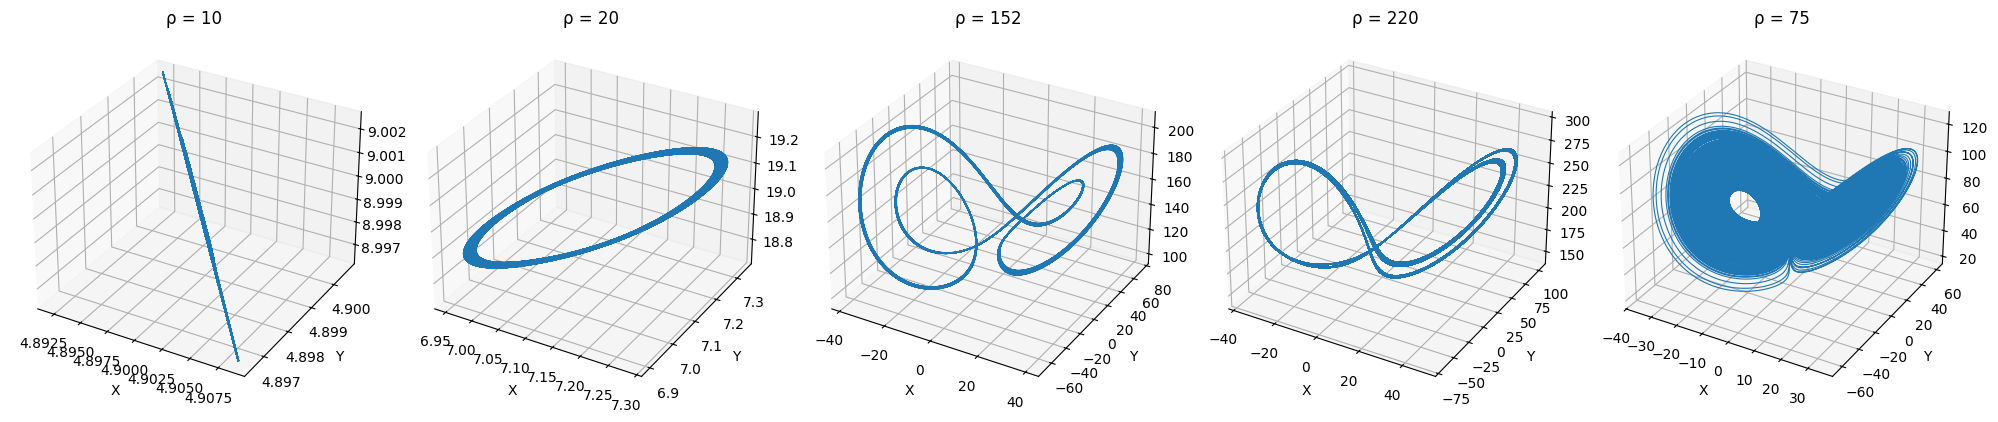

100 (20000, 3)


In [2]:
from koopstd.dynametric import KoopOpMetric
from koopstd.eval import MetricEvaluator
from koopstd.datasets import Lorenz63
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE, MDS
import pandas as pd

lorenz = Lorenz63(rho_values=[10, 20, 152, 220, 75], num_clips=20)
lorenz.visualize_data(time_range=None)

data = lorenz.data
print(len(data), data[0].shape)

In [6]:
# heatmap for distance matrix and scatter plot for MDS projection

def plot_results(distance_matrix, method_name, num_clips):
    # Create a figure with two subplots
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Plot heatmap
    sns.heatmap(distance_matrix, cmap='viridis', ax=axes[0])
    lorenz_names = ['Line-like', 'Ring-like', 'Periodic-1122', 'Periodic-11', 'Chaotic']
    axes[0].set_title('KoopSTD Distance Matrix')

    # Set custom tick labels
    tick_positions = [num_clips / 2, num_clips * 3 / 2, num_clips * 5 / 2, num_clips * 7 / 2, num_clips * 9 / 2] 
    axes[0].set_xticks(tick_positions)
    axes[0].set_yticks(tick_positions)
    axes[0].set_xticklabels(lorenz_names, rotation=45, ha='right')
    axes[0].set_yticklabels(lorenz_names, rotation=0)

    # Perform MDS for visualization
    vis = MDS(n_components=2, dissimilarity='precomputed', random_state=42)
    embedding = vis.fit_transform(distance_matrix)

    # Create DataFrame for scatter plot
    df = pd.DataFrame()
    df["x"] = embedding[:, 0]
    df["y"] = embedding[:, 1]

    # Add labels for different rho values (5 rho values, 40 clips each)
    rho_labels = []
    rho_values = [10, 20, 152, 220, 75]
    for rho in rho_values:
        rho_labels.extend([f"ρ={rho}"] * num_clips)
    df["System"] = rho_labels

    # Plot scatter with improved styling
    sns.scatterplot(data=df, x="x", y="y", hue="System", ax=axes[1], s=80, alpha=0.8)
    axes[1].set_title(f'MDS Projection of Results by {method_name}')
    axes[1].set_xlabel('MDS Component 1')
    axes[1].set_ylabel('MDS Component 2')
    axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    return plt

In [4]:
from sklearn.preprocessing import StandardScaler

subsample = 10

data = lorenz.data
ss = StandardScaler()
data = [ss.fit_transform(i) for i in data]
data = [i[::subsample] for i in data]
data[0].shape, len(data)

((2000, 3), 100)

### KoopSTD (Ours)

0.9653430602330465


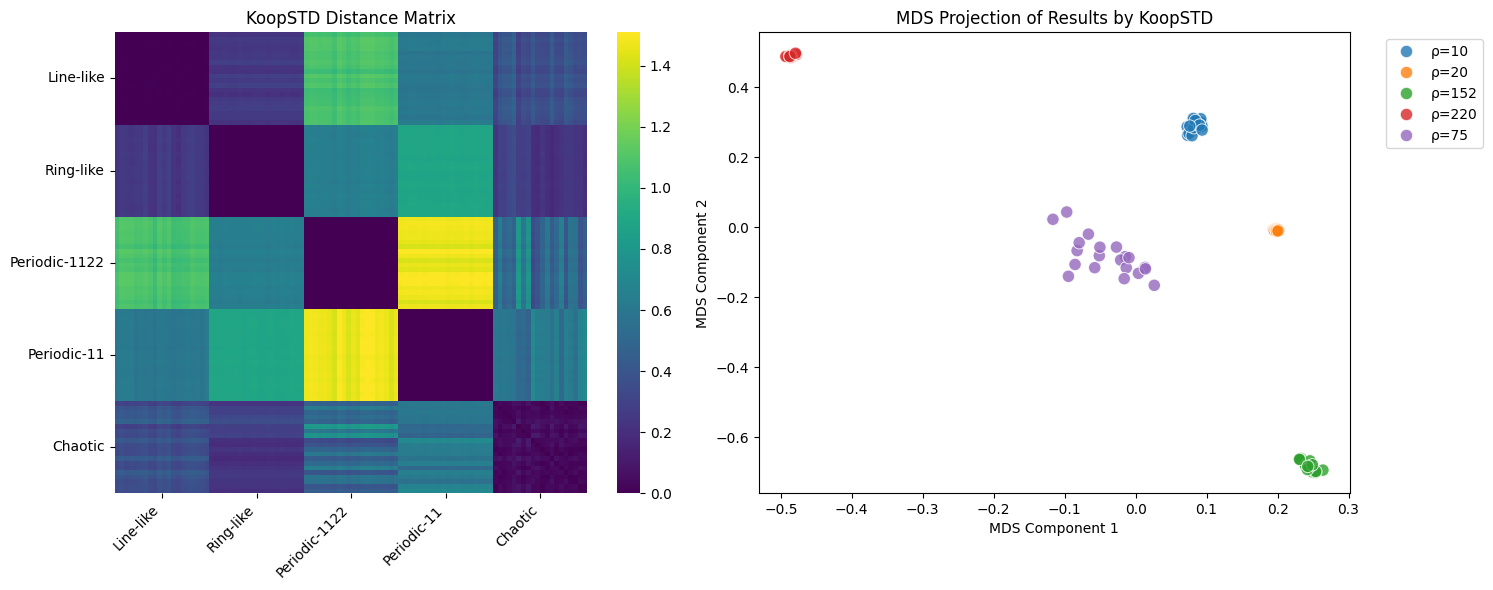

In [45]:
koopstd_params = {'hop_size': 1, 'win_len': 80, 'rank': 5, 'lamb': 0.1}  # hyper-parameters for KoopSTD(l,s,r)
wasserstein_params = {'p': 1, 'method': 'emd', 'feature_type': 'eig'}  # hyper-parameters for Wasserstein distance, either eig or sv is supported

koopstd = KoopOpMetric(X=data, kmd_method='koopstd', kmd_params=koopstd_params, dist='wasserstein', dist_params=wasserstein_params, device='cuda')
koopstd_dist_matrix = koopstd.fit_score()

# Evaluate the performance of KoopSTD by Silhouette Coefficient
me = MetricEvaluator(distance_matrix=koopstd_dist_matrix, cluster_sizes=[20, 20, 20, 20, 20])
silhouette = me.evaluate()
print(silhouette)

plt = plot_results(koopstd_dist_matrix, "KoopSTD", 20)
plt.show()

### HAVOK-based DSA

Next, we evaluate another Koopman operator-based metric for dynamical similarity: **DSA**, proposed by *Ostrow et al., 2024*. Due to the high computational time of PAVF in DSA on this large dataset, we also compute the Wasserstein distance between the eigenvalues of the approximated Koopman operator, following the same setup as in KoopSTD.

0.9977050804222237


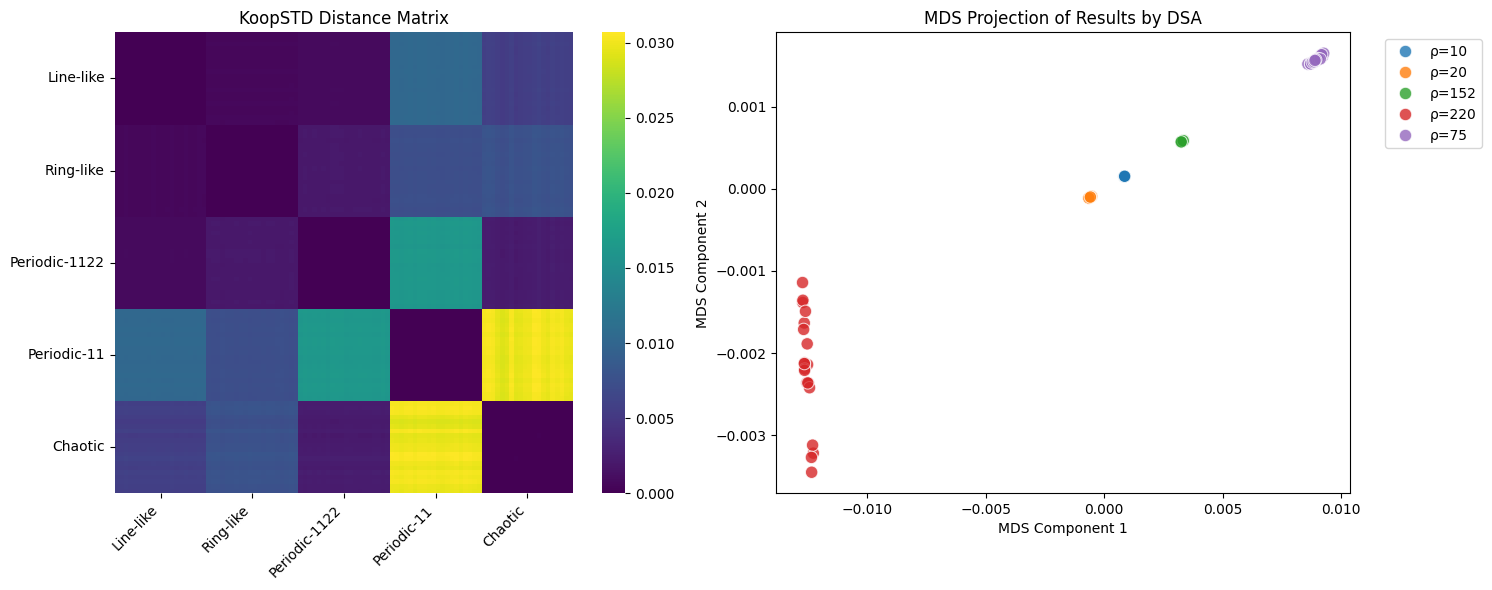

In [25]:
from DSA import DSA

dsa = DSA(data, n_delays=70, rank=6, verbose=False, score_method="wasserstein", device="cuda")
dsa_sim = dsa.fit_score()

me = MetricEvaluator(distance_matrix=dsa_sim, cluster_sizes=[20, 20, 20, 20, 20])
silhouette = me.evaluate()
print(silhouette)

plt = plot_results(dsa_sim, "DSA", 20)
plt.show()

We address the ongoing discussion regarding the silhouette score of DSA (Ostrow et al., 2024), which has persisted since the PR1 exchange last August. Following the original authors' comments, we revisited our DSA implementation and made the necessary corrections to align with its intended usage — specifically, adopting the official codebase and incorporating the recommended preprocessing steps, as also reflected in the authors' recent update (https://github.com/mitchellostrow/DSA/blob/main/examples/dsa_koopstd_fix.ipynb). Under this corrected protocol, DSA achieves near-perfect clustering performance (silhouette coefficient ≈ 0.998) on the five dynamical regimes of the Lorenz63 system. We appreciate the authors' clarification on these implementation details.

This exchange has, however, raised a question worth pausing on: is the silhouette coefficient actually the perfect tool for evaluating dynamical similarity metrics? The regimes considered here (fixed-point, periodic, and chaotic attractors) are of course qualitatively different, and we would naturally expect a good similarity metric to pick up on this; a reasonably high silhouette score is encouraging. But demanding 100% separability is arguably asking for too much, and perhaps the wrong thing entirely. These regimes are not as cleanly separated as the benchmark assumes: chaotic attractors are often organized around dense sets of unstable periodic orbits, and although their Koopman spectra differ formally, periodic and weakly chaotic regimes can still share aligned dominant spectral components and observable-dependent invariant structures, indicating that they do not form strictly disjoint dynamical classes. If anything, a metric that is truly sensitive to the underlying dynamics might be expected to reflect this shared structure to some extent, rather than pretend it isn't there. **We therefore question whether near-perfect separability is a meaningful objective in this setting; at best, it serves as a coarse indicator of whether a metric captures dynamical structure beyond geometry, but it is not a reliable basis for ranking dynamical similarity metrics.**

Fundamentally, our interest is not in achieving the highest possible metric scores on standard toy datasets like Lorenz63, but rather in **exploring the potential of these methods to offer insights on more meaningful, open, and high-dimensional problems**. We reiterate our appreciation for the original authors’ contribution in developing DSA, which has served as an important inspiration for subsequent work, including ours.